## XRD Analysis

##### Caleb Fink 4/24/26

In progress XRD analysis. This notebook imports the fitting class PeakFitXRD, which is saved in the corresponding python file XRD_fits.py. There are also some plotting functions that are saved in XRD_plot_utils.py

In [1]:
import sys; sys.path.append("..")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, approx_fprime
from scipy.special import voigt_profile
from math import lgamma
import re
import pickle as pkl

from glob import glob

from matplotlib import rcParams
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import voigt_profile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from XRD_fits import PeakFitXRD, fits_to_dataframe, compute_ratio_with_error
import XRD_plot_utils as pltxrd

%load_ext autoreload
%autoreload 2

In [3]:
# helper function to get labels
def get_jt_label(f):
    match = re.search(r'JT\d+', f)
    return match.group(0) if match else None

# dumb function to sort files by pressure
def sort_by_pressure(files, pressure_dict):
    files_sorted = sorted(
        files,
        key=lambda f: -pressure_dict[get_jt_label(f)]
    )
    return files_sorted

# put datafile into pandas dataframe
def read_data(f):
    df = pd.read_table(f, sep=r'\s+', names=['x', 'y', 'z'], skiprows=[0, 1])
    return df

#### Define pressures and load files

In [4]:
# define dictionary of preasures from JT
pressures = {'JT10' : -514,
             'JT9'  : -581,
             'JT8'  : -535,
             'JT7'  : -391,
             'JT6'  : -362,
             'JT5'  : -368,
             'JT4'  : -40.5,
             'JT3'  : -733,
             'JT2'  : -399,
             'JT1'  : -965,}

pressures_error = {'JT10' : 29.663057,
             'JT9'  : 38.538617	,
             'JT8'  : 49.497283	,
             'JT7'  : 20.284586,
             'JT6'  : 24.108864	,
             'JT5'  : 27.798575	,
             'JT4'  : 30.171437,
             'JT3'  : 68.165019	,
             'JT2'  : 53.947341	,
             'JT1'  : 68.120334	,}



files = glob('../data/20250611_JT_re plot/20250611_JT*')
# filter out junk files - all these files are not to be used? check with JT
bad_words = ['Si', 'rot', 'JT4', '3090']

# remove 'bad' files 
files_high = [f for f in files if not any(word in f for word in bad_words)]
files_low = glob('../data/20250611_JT_re plot/JT*')

# sort the files by pressure
files_high = sort_by_pressure(files_high, pressures)
files_low = sort_by_pressure(files_low, pressures)


# check the order
for ii, f in enumerate(files_high):
    print(pressures[get_jt_label(files_high[ii])])




-362
-368
-391
-399
-514
-535
-581
-733
-965


In [5]:
with open("../data/processed_data/high_signal_XRD_df.pkl", 'rb') as file:
    df_high = pkl.load(file)
with open("../data/processed_data/low_signal_XRD_df.pkl", 'rb') as file:
    df_low = pkl.load(file)
df_low

,label,A1,A2,x0,x2,sigma,gamma,delta,c0,delta_AIC,...,A1_A2_cov,A2_over_A1,A2_over_A1_err,x0_errm_prof,x0_errp_prof,delta_errm_prof,delta_errp_prof,x2_errm_prof,x2_errp_prof,stress
0,JT4,23.521454,0.592364,38.415832,38.973680,0.182889,0.124428,0.557848,0.023664,2.733575,...,-0.519358,0.025184,0.030195,NaN,0.012606,NaN,NaN,NaN,NaN,-40.5
1,JT6,75.454170,3.554683,38.250124,38.684538,0.174374,0.073310,0.434414,0.000000,-8.125769,...,-2.346438,0.047110,0.021743,0.007684,0.006200,NaN,NaN,NaN,NaN,-362.0
2,JT5,36.300193,1.334933,38.241779,38.876659,0.219912,0.086678,0.634880,0.068562,-2.419142,...,-0.625692,0.036775,0.023455,0.013740,0.009894,NaN,NaN,NaN,NaN,-368.0
3,JT7,179.297932,5.443734,38.260937,38.712004,0.162343,0.048760,0.451067,0.000000,-29.211571,...,-1.890095,0.030361,0.008043,0.002727,0.003417,0.040183,0.040896,0.040275,0.041039,-391.0
4,JT2,53.693843,2.267435,38.221132,38.819537,0.193430,0.066394,0.598404,0.000000,-17.909195,...,-0.445410,0.042229,0.013105,0.006216,0.006819,NaN,NaN,NaN,NaN,-399.0
5,JT10,293.564437,11.322878,38.196934,38.662907,0.155181,0.041032,0.465973,0.000000,-118.177579,...,-1.962952,0.038570,0.005166,0.001724,0.002429,0.018605,0.022486,0.018685,0.022617,-514.0
6,JT8,63.844918,3.488927,38.153749,38.688080,0.193151,0.072827,0.534331,0.070274,-17.048038,...,-1.426332,0.054647,0.020554,0.008714,0.007068,NaN,NaN,NaN,NaN,-535.0
7,JT9,129.335361,3.069437,38.103820,38.664010,0.168342,0.058732,0.560191,0.000000,-19.922775,...,-0.769599,0.023732,0.006854,0.003920,0.002903,NaN,NaN,NaN,NaN,-581.0
8,JT3,78.330604,6.481680,38.127195,38.672998,0.179412,0.066510,0.545803,0.000000,-76.301559,...,-0.888835,0.082748,0.013879,0.005977,0.005056,0.035973,0.035735,0.036466,0.036091,-733.0
9,JT1,177.150673,11.134983,38.029201,38.503744,0.163473,0.063205,0.474542,0.000000,-91.937311,...,-2.956990,0.062856,0.010760,0.003385,0.004079,0.028064,0.030575,0.028268,0.030846,-965.0


In [6]:
df_high['stress_err'] = df_high['label'].map(pressures_error)
df_low['stress_err'] = df_low['label'].map(pressures_error)
df_low

,label,A1,A2,x0,x2,sigma,gamma,delta,c0,delta_AIC,...,A2_over_A1,A2_over_A1_err,x0_errm_prof,x0_errp_prof,delta_errm_prof,delta_errp_prof,x2_errm_prof,x2_errp_prof,stress,stress_err
0,JT4,23.521454,0.592364,38.415832,38.973680,0.182889,0.124428,0.557848,0.023664,2.733575,...,0.025184,0.030195,NaN,0.012606,NaN,NaN,NaN,NaN,-40.5,30.171437
1,JT6,75.454170,3.554683,38.250124,38.684538,0.174374,0.073310,0.434414,0.000000,-8.125769,...,0.047110,0.021743,0.007684,0.006200,NaN,NaN,NaN,NaN,-362.0,24.108864
2,JT5,36.300193,1.334933,38.241779,38.876659,0.219912,0.086678,0.634880,0.068562,-2.419142,...,0.036775,0.023455,0.013740,0.009894,NaN,NaN,NaN,NaN,-368.0,27.798575
3,JT7,179.297932,5.443734,38.260937,38.712004,0.162343,0.048760,0.451067,0.000000,-29.211571,...,0.030361,0.008043,0.002727,0.003417,0.040183,0.040896,0.040275,0.041039,-391.0,20.284586
4,JT2,53.693843,2.267435,38.221132,38.819537,0.193430,0.066394,0.598404,0.000000,-17.909195,...,0.042229,0.013105,0.006216,0.006819,NaN,NaN,NaN,NaN,-399.0,53.947341
5,JT10,293.564437,11.322878,38.196934,38.662907,0.155181,0.041032,0.465973,0.000000,-118.177579,...,0.038570,0.005166,0.001724,0.002429,0.018605,0.022486,0.018685,0.022617,-514.0,29.663057
6,JT8,63.844918,3.488927,38.153749,38.688080,0.193151,0.072827,0.534331,0.070274,-17.048038,...,0.054647,0.020554,0.008714,0.007068,NaN,NaN,NaN,NaN,-535.0,49.497283
7,JT9,129.335361,3.069437,38.103820,38.664010,0.168342,0.058732,0.560191,0.000000,-19.922775,...,0.023732,0.006854,0.003920,0.002903,NaN,NaN,NaN,NaN,-581.0,38.538617
8,JT3,78.330604,6.481680,38.127195,38.672998,0.179412,0.066510,0.545803,0.000000,-76.301559,...,0.082748,0.013879,0.005977,0.005056,0.035973,0.035735,0.036466,0.036091,-733.0,68.165019
9,JT1,177.150673,11.134983,38.029201,38.503744,0.163473,0.063205,0.474542,0.000000,-91.937311,...,0.062856,0.010760,0.003385,0.004079,0.028064,0.030575,0.028268,0.030846,-965.0,68.120334


In [7]:
def plot_two_peak_components(x, counts, A1, x0, sigma, gamma, A2, delta, c0,
                             stress=None, ax=None, simple=False):
    cmap = cm.get_cmap('plasma')
    c_peak1 = cmap(0.10)
    c_peak2 = cmap(0.45)
    c_total = cmap(0.72)
    c_bkg   = cmap(0.92)

    FONTSIZE_LABEL  = 14
    FONTSIZE_TICK   = 12
    FONTSIZE_LEGEND = 9
    FONTSIZE_TITLE  = 14

    x = np.asarray(x, dtype=float)
    counts = np.asarray(counts, dtype=float)

    peak1 = A1 * voigt_profile(x - x0, sigma, gamma)
    peak2 = A2 * voigt_profile(x - (x0 + delta), sigma, gamma)
    bkg   = np.full_like(x, c0)
    total = peak1 + peak2 + bkg

    if ax is None:
        fig, ax = plt.subplots(figsize=(3.0, 2.4))

    ax.step(x, counts, color='k', lw=1.2, label='data', where='mid')
    ax.plot(x, total, lw=2.0, color=c_total, label='total fit')

    if not simple:
        ax.plot(x, peak1, '--', lw=1.8, color=c_peak1, label='peak 1')
        ax.plot(x, peak2, ':',  lw=1.8, color=c_peak2, label='peak 2')
        ax.plot(x, bkg,   '-.', lw=1.4, color=c_bkg,   label='background')

    ax.set_yscale('log')
    ax.set_xlabel(r'2$\theta$ [°]', fontsize=FONTSIZE_LABEL)
    ax.set_ylabel('Counts',         fontsize=FONTSIZE_LABEL)

    if stress is not None:
        ax.set_title(f'Stress = {stress} MPa', fontsize=FONTSIZE_TITLE)

    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=FONTSIZE_TICK)
    ax.minorticks_on()

    if not simple:
        ax.legend(fontsize=FONTSIZE_LEGEND, frameon=False,
                  loc='lower center', ncol=3, columnspacing=1.0)

    ax.set_xlim(x.min(), x.max())
    return ax

/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_54713/1514016094.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


<Axes: xlabel='2$\\theta$ [°]', ylabel='Counts'>

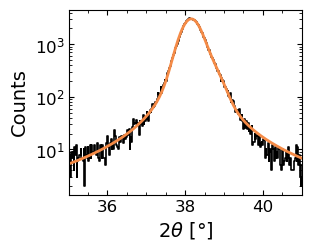

In [8]:
ii = 7

row = df_high.iloc[ii]  # or however you select the fit
f = files_high[ii]
raw_df = read_data(f)

c_high = raw_df.x > 35
c_low = ((raw_df.x > 35) & (raw_df.x < 41))

x = raw_df.x[c_high]
counts = raw_df.y[c_high]

plot_two_peak_components(
    x, counts,
    row.A1, row.x0, row.sigma, row.gamma, row.A2, row.delta, row.c0, simple=True
)

In [9]:
def plot_x0_vs_stress(df, df2=None, ax=None, color_idx=0.30,
                      sweep_labels=('sweep 1', 'sweep 2'),
                      highlight_stress=None, highlight_sweep=1,
                      inset_func=None, inset_bounds=None):
    cmap = cm.get_cmap('plasma')
    c_data1 = cmap(color_idx)
    c_data2 = cmap(color_idx + 0.25)
    c_highlight = cmap(0.72)

    FONTSIZE_LABEL  = 14
    FONTSIZE_TICK   = 12
    FONTSIZE_LEGEND = 10

    if ax is None:
        fig, ax = plt.subplots(figsize=(4.0, 3.2))

    def _get_yerr(d):
        has_prof = ('x0_errm_prof' in d.columns and 'x0_errp_prof' in d.columns
                    and d['x0_errm_prof'].notna().any())
        has_hess = 'x0_err2_hess' in d.columns and d['x0_err2_hess'].notna().any()
        if has_prof:
            return np.array([d['x0_errm_prof'].values, d['x0_errp_prof'].values])
        elif has_hess:
            return d['x0_err2_hess'].values
        return None

    def _plot_sweep(d, color, marker, label):
        d = d.dropna(subset=['stress', 'x0']).sort_values('stress')
        yerr = _get_yerr(d)
        xerr = d['stress_err']
        ax.errorbar(d['stress'], d['x0'], yerr=yerr, xerr=xerr,
                    fmt=marker, ms=6.25, lw=2.5, capsize=5, capthick=2,
                    color=color, ecolor=color, markeredgecolor='k',
                    markeredgewidth=0.5, zorder=5, label=label)
    
    _plot_sweep(df, c_data1, 'o', sweep_labels[0])

    
    if df2 is not None:
        _plot_sweep(df2, c_data2, 's', sweep_labels[1])
        #_plot_sweep(df, c_data1, 'o', sweep_labels[0])

    # ── highlight only the sweep the inset comes from ────────
    if highlight_stress is not None:
        h_df = df if highlight_sweep == 1 else df2
        h_marker = 'o' if highlight_sweep == 1 else 's'
        if h_df is not None:
            h = h_df[h_df['stress'] == highlight_stress]
            if not h.empty:
                ax.plot(h['stress'], h['x0'], h_marker, ms=7,
                        color=c_highlight, markeredgecolor='k',
                        markeredgewidth=0.8, zorder=6)

    ax.set_xlabel('Stress [MPa]', fontsize=FONTSIZE_LABEL)
    ax.set_ylabel(r'$2\theta_0$ [°]', fontsize=FONTSIZE_LABEL)

    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=FONTSIZE_TICK)
    ax.minorticks_on()

    if df2 is not None:
        ax.legend(fontsize=FONTSIZE_LEGEND, frameon=False, loc='lower right')

    # ── inset ────────────────────────────────────────────────
    if inset_func is not None:
        import matplotlib.ticker as mticker
        
        
        bounds = inset_bounds or [0.05, 0.52, 0.42, 0.45]
        ax_inset = ax.inset_axes(bounds)
        inset_func(ax_inset)
        ax_inset.tick_params(axis='both', which='both', direction='in',
                             top=True, right=True, labelsize=7)
        ax_inset.xaxis.label.set_size(8)
        ax_inset.yaxis.label.set_size(8)
        if ax_inset.get_title():
            ax_inset.set_title('')
        if ax_inset.get_legend():
            ax_inset.get_legend().remove()
        ax_inset.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=4))
        ax_inset.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs='auto', numticks=4))
        ax_inset.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax_inset.yaxis.tick_right()
        ax_inset.yaxis.set_label_position('right')

    return ax

In [26]:
def plot_x0_vs_stress_combined(df, df2=None, ax=None, color_idx=0.30,
                                highlight_stress=None, highlight_sweep=1,
                                inset_func=None, inset_bounds=None):
    cmap = cm.get_cmap('plasma')
    c_data = cmap(color_idx)
    c_highlight = cmap(0.72)
    FONTSIZE_LABEL  = 14
    FONTSIZE_TICK   = 12

    if ax is None:
        fig, ax = plt.subplots(figsize=(4.0, 3.2))

    def _get_yerr(d):
        has_prof = ('x0_errm_prof' in d.columns and 'x0_errp_prof' in d.columns
                    and d['x0_errm_prof'].notna().any())
        has_hess = 'x0_err2_hess' in d.columns and d['x0_err2_hess'].notna().any()
        if has_prof:
            return np.array([d['x0_errm_prof'].values, d['x0_errp_prof'].values])
        elif has_hess:
            return d['x0_err2_hess'].values
        return None

    # ── combine dataframes ───────────────────────────────────
    if df2 is not None:
        d_all = pd.concat([df, df2], ignore_index=True)
    else:
        d_all = df.copy()

    d_all = d_all.dropna(subset=['stress', 'x0']).sort_values('stress')
    yerr = _get_yerr(d_all)
    xerr = d_all['stress_err'] if 'stress_err' in d_all.columns else None

    ax.errorbar(d_all['stress'], d_all['x0'], yerr=yerr, xerr=xerr,
                fmt='o', ms=6.25, lw=2.5, capsize=5, capthick=2,
                color=c_data, ecolor=c_data, markeredgecolor='k',
                markeredgewidth=0.5, zorder=5)

    # ── highlight ────────────────────────────────────────────
    if highlight_stress is not None:
        h_df = df if highlight_sweep == 1 else df2
        if h_df is not None:
            h = h_df[h_df['stress'] == highlight_stress]
            if not h.empty:
                # ax.plot(h['stress'], h['x0'], 'o', ms=7,
                #         color=c_highlight, markeredgecolor='k',
                #         markeredgewidth=0.8, zorder=6)
                ax.errorbar(h['stress'], h['x0'], yerr=_get_yerr(h), xerr=h['stress_err'],
                fmt='o', ms=6.25, lw=2.5, capsize=5, capthick=2,
                color=c_highlight, ecolor=c_highlight, markeredgecolor='k',
                markeredgewidth=0.5, zorder=10)

    ax.set_xlabel('Stress [MPa]', fontsize=FONTSIZE_LABEL)
    ax.set_ylabel(r'$2\theta_0$ [°]', fontsize=FONTSIZE_LABEL)
    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=FONTSIZE_TICK)
    ax.minorticks_on()

    # ── inset ────────────────────────────────────────────────
    if inset_func is not None:
        import matplotlib.ticker as mticker

        bounds = inset_bounds or [0.05, 0.52, 0.42, 0.45]
        ax_inset = ax.inset_axes(bounds)
        inset_func(ax_inset)
        ax_inset.tick_params(axis='both', which='both', direction='in',
                             top=True, right=True, labelsize=7)
        ax_inset.xaxis.label.set_size(8)
        ax_inset.yaxis.label.set_size(8)
        if ax_inset.get_title():
            ax_inset.set_title('')
        if ax_inset.get_legend():
            ax_inset.get_legend().remove()
        ax_inset.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=4))
        ax_inset.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs='auto', numticks=4))
        ax_inset.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax_inset.yaxis.tick_right()
        ax_inset.yaxis.set_label_position('right')

    # ── return combined x, y for fitting ─────────────────────
    x_combined = d_all['stress'].values
    y_combined = d_all['x0'].values

    return ax, x_combined, y_combined, yerr, xerr

slope = 0.000503 ± 0.000042 °/MPa


/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_54713/639338268.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')
/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_54713/1514016094.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


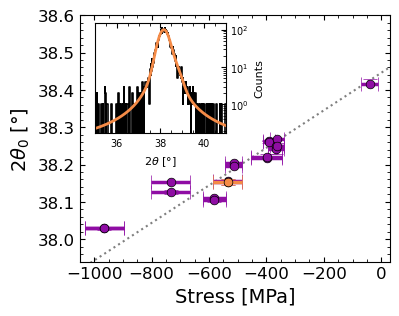

In [41]:
ii = 7
ii = 6


f = files_high[ii]
raw_df = read_data(f)
row = df_high.iloc[ii] 

f = files_low[ii]
raw_df = read_data(f)
row = df_low.iloc[ii] 


c_high = raw_df.x > 35
c_low = ((raw_df.x > 35) & (raw_df.x < 41))

x = raw_df.x[c_low]
counts = raw_df.y[c_low]

ax, x_all, y_all, y_err_all, x_err_all = plot_x0_vs_stress_combined(
    df_high, df2=df_low,
    highlight_stress=row.stress, highlight_sweep=2,
    inset_func=lambda ax_in: plot_two_peak_components(
        x, counts,
        row.A1, row.x0, row.sigma, row.gamma, row.A2, row.delta, row.c0,
        ax=ax_in, simple=True,
    ),
)


from scipy.odr import ODR, Model, RealData

linear_model = Model(lambda B, x: B[0] * x + B[1])
data = RealData(x_all, y_all, sx=x_err_all, sy=y_err_simp)
odr = ODR(data, linear_model, beta0=[1e-4, 38.0])
out = odr.run()

slope, intercept = out.beta
slope_err = out.sd_beta[0]
print(f"slope = {slope:.6f} ± {slope_err:.6f} °/MPa")


x_fit = np.linspace(x_all.min()*1.2, 40, 100)
ax.plot(x_fit, np.polyval(out.beta, x_fit), ':', color='k', lw=1.5, alpha=.5)
ax.set_xlim(-1050,30)
ax.set_ylim(37.94, 38.6)
plt.savefig('x0_vs_stress_combined.pdf', bbox_inches='tight')



In [15]:
print(y_err_simp.min(), np.any(y_err_simp == 0), np.any(np.isnan(y_err_simp)))

nan False True


In [21]:
 y_err_all[1]

array([0.00407884, 0.00026846, 0.00053332, 0.00505618, 0.00028023,
       0.00290342, 0.00067299, 0.00706809, 0.00092561, 0.00242914,
       0.00079103, 0.00681924, 0.00099489, 0.00341699, 0.00110907,
       0.00989416, 0.00057109, 0.00620006, 0.01260603])

/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_54132/2608302809.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')
/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_54132/1514016094.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


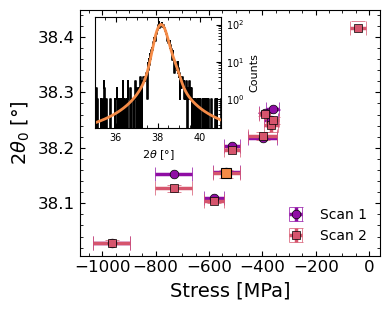

In [15]:
ii = 7
ii = 6


f = files_high[ii]
raw_df = read_data(f)
row = df_high.iloc[ii] 

f = files_low[ii]
raw_df = read_data(f)
row = df_low.iloc[ii] 


c_high = raw_df.x > 35
c_low = ((raw_df.x > 35) & (raw_df.x < 41))

x = raw_df.x[c_low]
counts = raw_df.y[c_low]

plot_x0_vs_stress(
    df_high, df2=df_low,
    sweep_labels=('Scan 1', 'Scan 2'),
    highlight_stress=row.stress, highlight_sweep=2,
    inset_func=lambda ax_in: plot_two_peak_components(
        x, counts,
        row.A1, row.x0, row.sigma, row.gamma, row.A2, row.delta, row.c0,
        ax=ax_in, simple=True,
    ),
)
plt.tight_layout()
plt.savefig('x0_vs_stress.pdf')
plt.savefig('x0_vs_stress.png', dpi=350)